### DSBA M1
## Econometrics
Prof. Roberto Renò - ESSEC Business School 

## Homework 2


In [1]:
import numpy as np
import pandas as pd
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv("Inflation_France_OECD.csv", sep=';')
data = data.set_index("Time")
data.head()

,CPI
Time,
Jan-00,1.5
Feb-00,1.4
Mar-00,1.5
Apr-00,1.2
May-00,1.4


## Forecasting inflation

# Questions

1. Make a table with standard descriptive statistics for CPI. Make a time series plot and a sample autocorrelation and partial autocorrelation plot. Interpret.
2. Discard the last 50% of your observations, they will be used below for evaluating forecasts. Using the remaining 50% of the data, estimate a AR(1) model for CPIt.
3. Forecasting exercise: Given the AR(1) model, for the last 50% of your observations, make forecasts for horizon 1 to 6 months. Re-estimate your model parameters after every forecast. Store your parameter estimates and make a plot of them once the forecasting exercise is finished. Check visually for breaks in the parameter estimates.

(Example of a recursive forecasting procedure with 20% out-of-sample and forecast horizon 1 and 4: We have 100 observations initially. We keep 20 observations for forecast evaluation. We determine the best model with 80 observations. Given this best model we forecast observations 81 (horizon 1) and 84 (horizon 4) and we store the forecasts. Next, we estimate the same best model again using 81 observations and forecast observations 82 and 85 and store them. Continue with this procedure until the end of the sample. Doing this, we obtain a series of horizon 1 forecasts and horizon 4 forecasts.)

4. Compute horizon 1 to horizon 6 forecast errors using the last 50% of your observations. Compute the root mean squared forecast error (RMSE).

5. Do the same forecasting exercise for a naive forecasting model which computes as forecast the mean of the last 12 CPI observations.

6. Print a summary table with the root mean squared forecast error (RMSE) for the three models and different forecast horizons. Discuss which model is best for which horizon.

7. Make a time series plot of the forecast errors and discuss the forecasting performance over time.

# Question 1

In [3]:
# 1.1 Descriprive info
data.describe()

,CPI
count,206.000000
mean,1.440777
std,0.861019
min,-0.700000
25%,0.900000
50%,1.600000
75%,2.000000
max,3.600000


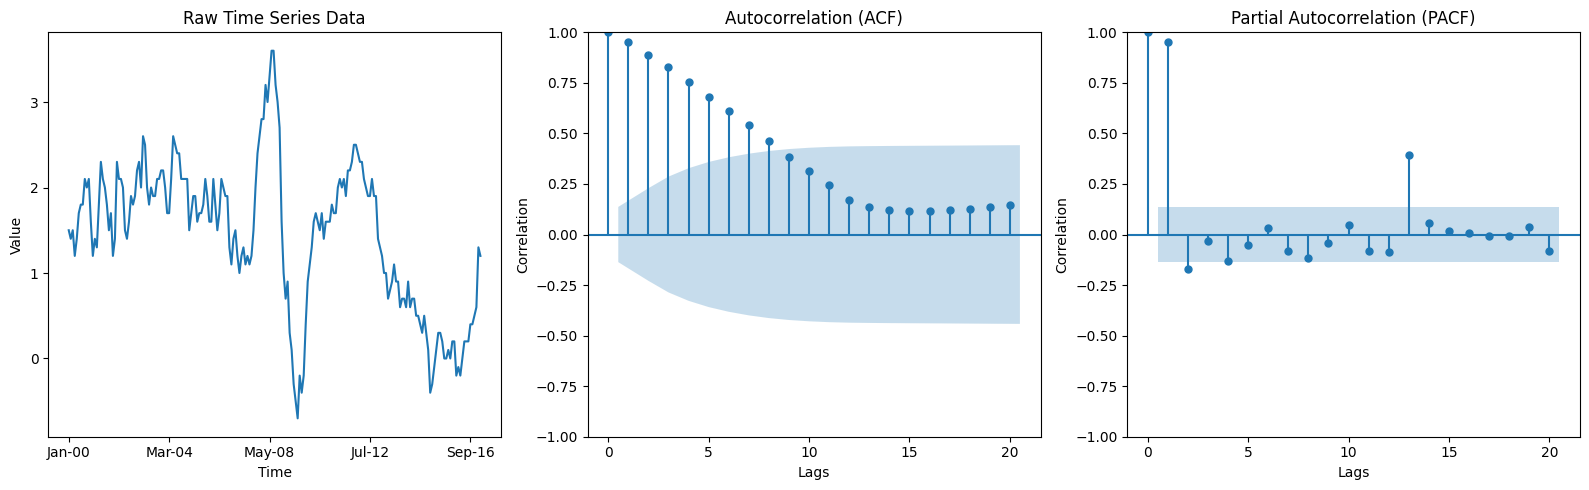

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].plot(data, )
axes[0].set_xticks([0,50,100,150,200])
axes[0].set_title('Raw Time Series Data')
axes[0].set_xlabel('Time')
axes[0].set_ylabel('Value')

plot_acf(data, ax=axes[1], lags=20)
axes[1].set_title('Autocorrelation (ACF)')
axes[1].set_xlabel('Lags')
axes[1].set_ylabel('Correlation')


plot_pacf(data, ax=axes[2], lags=20)
axes[2].set_title('Partial Autocorrelation (PACF)')
axes[2].set_xlabel('Lags')
axes[2].set_ylabel('Correlation')


plt.tight_layout()
plt.show()


The single spike in the PACF at lag 1 suggests an autoregressive relationship, however the extremely slow, linear decay of the ACF and the PACF value approaching 1.0 indicate that the CPI series is non-stationary but rather likelyto be a random walk process.

# Question 2

In [5]:
first_half_data=data.iloc[:len(data)//2]
model = ARIMA(first_half_data["CPI"], order=(1,0,0))
results = model.fit()
print(results.summary())

                               SARIMAX Results                                
Dep. Variable:                    CPI   No. Observations:                  103
Model:                 ARIMA(1, 0, 0)   Log Likelihood                 -12.626
Date:                Sun, 31 May 2026   AIC                             31.253
Time:                        16:02:28   BIC                             39.157
Sample:                             0   HQIC                            34.454
                                - 103                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.9855      0.235      8.434      0.000       1.524       2.447
ar.L1          0.8897      0.056     15.928      0.000       0.780       0.999
sigma2         0.0737      0.010      7.291      0.0

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:559: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  _index = to_datetime(index)
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:559: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  _index = to_datetime(index)
/Library/Fram

# Question 3

<>:19: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:21: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:19: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:21: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
/tmp/claude-501/ipykernel_34920/464180038.py:19: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
  plt.title('Recursive Estimates of AR(1) Parameter ($\phi$)')
/tmp/claude-501/ipykernel_34920/464180038.py:21: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not w

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:559: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  _index = to_datetime(index)
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmod

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:559: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  _index = to_datetime(index)
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmod

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:559: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  _index = to_datetime(index)
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmod

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:559: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  _index = to_datetime(index)
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmod

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:559: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  _index = to_datetime(index)
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmod

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:559: UserWarning: Could not infer format, so 

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:559: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  _index = to_datetime(index)
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmod

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:559: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  _index = to_datetime(index)
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmod

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:559: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  _index = to_datetime(index)
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmod

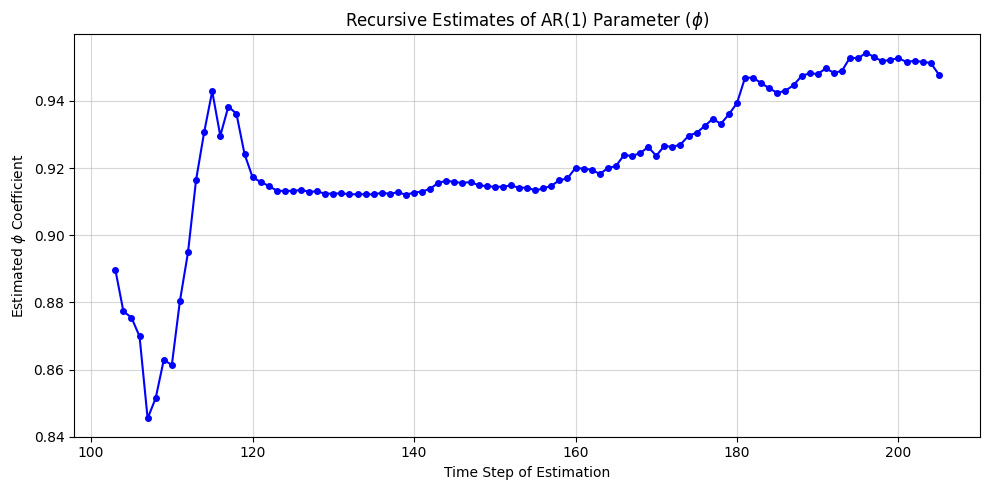

In [6]:
phi_estimates = []
forecast_storage = {}

for t in range(len(data)//2, len(data)):
    train_data = data.iloc[:t]
    model_loop = ARIMA(train_data, order=(1,0,0))
    results_loop = model_loop.fit()
    current_phi = results_loop.arparams[0]
    phi_estimates.append(current_phi)
    forecast = results_loop.forecast(steps=6)
    forecast_storage[t] = forecast.values


estimation_steps = range(len(data)//2, len(data))

plt.figure(figsize=(10, 5))
plt.plot(estimation_steps, phi_estimates, marker='o', markersize=4, linestyle='-', color='blue')

plt.title('Recursive Estimates of AR(1) Parameter ($\phi$)')
plt.xlabel('Time Step of Estimation')
plt.ylabel('Estimated $\phi$ Coefficient')
plt.grid(True, alpha=0.5)

plt.tight_layout()
plt.show()

The initial volatility between steps 100 and 120 is likely due to small-sample sensitivity. The parameter estimate then stabilizes at approximately 0.915 from step 120. Beginning around time step 160, we observe a clear structural break where the estimated AR(1) coefficient begins to steadily increasing toward 0.95.

# Question 4

In [7]:
horizons = 6
eval_steps = range(len(data) // 2, len(data))

errors_ar1 = {1: [], 2: [], 3: [], 4: [], 5: [], 6: []}

for t in eval_steps:
    for h in range(1, horizons + 1):
        if (t + h - 1) < len(data):  
            actual_value = data['CPI'].iloc[t + h - 1]
            predicted_value = forecast_storage[t][h - 1] 
            
            forecast_error = actual_value - predicted_value
            errors_ar1[h].append(forecast_error)

rmse_ar1 = []
print(" Analysis of horizons 1 to 6 using RMSE for AR(1) Model")

for h in range(1, horizons + 1):
    mse = np.mean(np.square(errors_ar1[h]))
    rmse = np.sqrt(mse)
    
    rmse_ar1.append(rmse)
    print(f"Horizon {h}: {rmse:.4f}")

 Analysis of horizons 1 to 6 using RMSE for AR(1) Model
Horizon 1: 0.2587
Horizon 2: 0.4045
Horizon 3: 0.5349
Horizon 4: 0.6468
Horizon 5: 0.7336
Horizon 6: 0.7999


# Question 5

In [8]:
errors_naive = {1: [], 2: [], 3: [], 4: [], 5: [], 6: []}

for t in eval_steps:
    if t >= 12:
        naive_forecast = data['CPI'].iloc[t-12 : t].mean()
    else:
        naive_forecast = data['CPI'].iloc[:t].mean()
        
    for h in range(1, horizons + 1):
        if (t + h - 1) < len(data):  
            actual_value = data['CPI'].iloc[t + h - 1]
            
            forecast_error = actual_value - naive_forecast
            errors_naive[h].append(forecast_error)

rmse_naive = []
print(" Analysis of horizons 1 to 6 using RMSE for Naive Model (12-month mean) ")

for h in range(1, horizons + 1):
    mse = np.mean(np.square(errors_naive[h]))
    rmse = np.sqrt(mse)
    
    rmse_naive.append(rmse)
    print(f"Horizon {h}: {rmse:.4f}")

 Analysis of horizons 1 to 6 using RMSE for Naive Model (12-month mean) 
Horizon 1: 0.7939
Horizon 2: 0.8801
Horizon 3: 0.9576
Horizon 4: 1.0263
Horizon 5: 1.0825
Horizon 6: 1.1251


# Question 6

In [9]:
# Computing the 3rd model rmse assuming a random walk model
errors_rw = {1: [], 2: [], 3: [], 4: [], 5: [], 6: []}

for t in eval_steps:
    rw_forecast = data['CPI'].iloc[t-1] # The Random Walk forecast is simply the last observed value at time t 
    
    for h in range(1, horizons + 1):
        if (t + h - 1) < len(data):  
            actual_value = data['CPI'].iloc[t + h - 1]
            forecast_error = actual_value - rw_forecast
            errors_rw[h].append(forecast_error)

rmse_random_walk = []
print("Analysis of horizons 1 to 6 using RMSE for Random Walk Model")

for h in range(1, horizons + 1):
    mse = np.mean(np.square(errors_rw[h]))
    rmse = np.sqrt(mse)
    rmse_random_walk.append(rmse)
    print(f"Horizon {h}: RMSE = {rmse:.4f}")

Analysis of horizons 1 to 6 using RMSE for Random Walk Model
Horizon 1: RMSE = 0.2558
Horizon 2: RMSE = 0.4028
Horizon 3: RMSE = 0.5418
Horizon 4: RMSE = 0.6669
Horizon 5: RMSE = 0.7656
Horizon 6: RMSE = 0.8467


In [10]:
rmse_data = {
    'Forecast Horizon': [1, 2, 3, 4, 5, 6],
    'AR(1) Model': rmse_ar1,
    'Naive (12-Month Mean)': rmse_naive,
    'Naive (Random Walk)': rmse_random_walk
}

rmse_summary = pd.DataFrame(rmse_data)

rmse_summary.set_index('Forecast Horizon', inplace=True)

print("RMSE Summary Table:")
display(rmse_summary)

RMSE Summary Table:


,AR(1) Model,Naive (12-Month Mean),Naive (Random Walk)
Forecast Horizon,,,
1,0.258720,0.793937,0.255806
2,0.404482,0.880066,0.402809
3,0.534897,0.957567,0.541816
4,0.646840,1.026343,0.666858
5,0.733560,1.082472,0.765612
6,0.799894,1.125104,0.846662


In a general manner, we look for the model with the lowest error. Interestingly, the naive random walk is the best model at short horizons (h=1 and h=2), but the AR(1) takes over from horizon 3 onwards, achieving the lowest RMSE. The 12-month mean model is the worst across all horizons. Unlike the two naive models, the AR(1) RMSE grows more slowly with the horizon thanks to its mean-reverting structure.
For longer horizons, the stationarity of the AR(1) model will keep the error variance bounded whereas the forecast error of the random walk will eventually diverge to infinity.

# Question 7

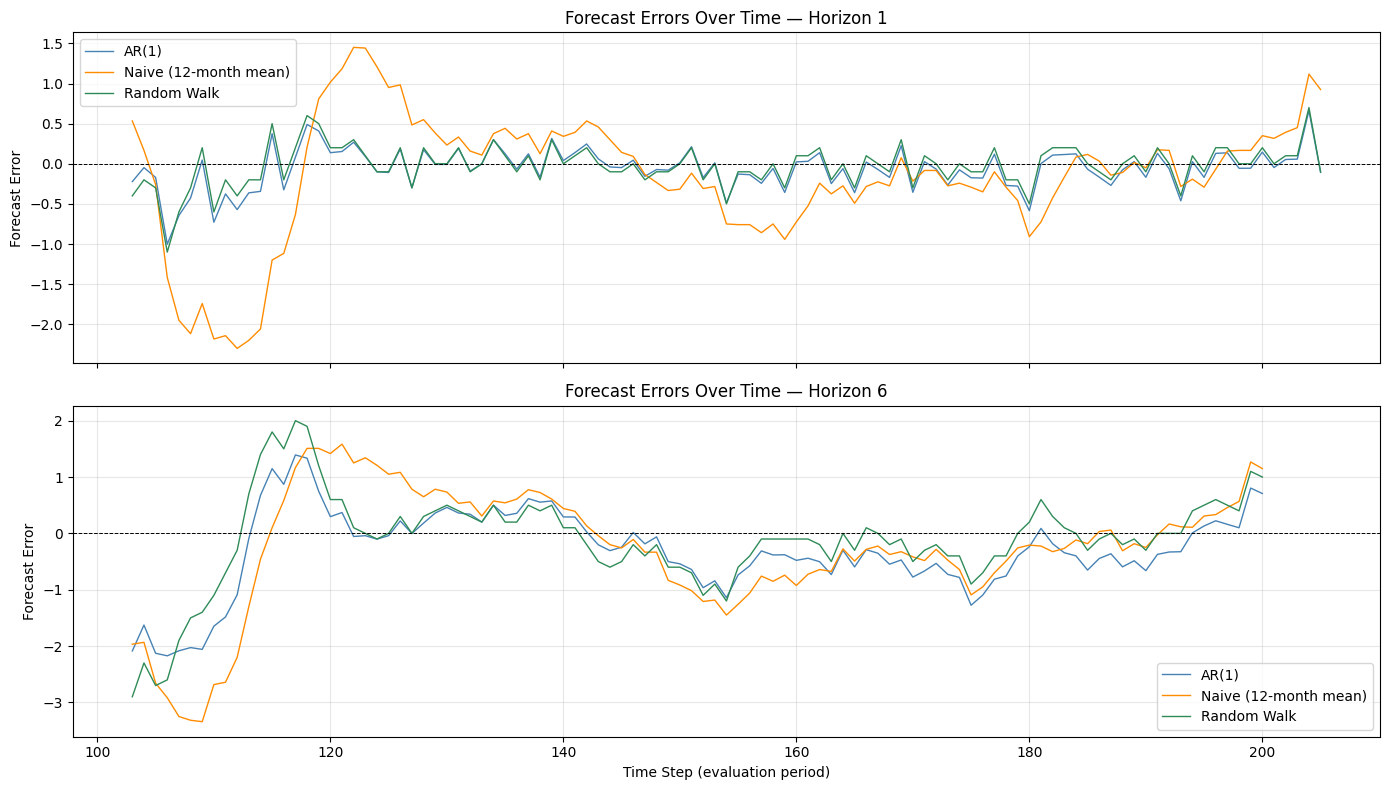

In [11]:
eval_time = list(range(len(data) // 2, len(data)))

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

for h_plot, ax in zip([1, 6], axes):
    ax.plot(eval_time[:len(errors_ar1[h_plot])],   errors_ar1[h_plot],   label='AR(1)',               color='steelblue',  linewidth=1)
    ax.plot(eval_time[:len(errors_naive[h_plot])], errors_naive[h_plot], label='Naive (12-month mean)', color='darkorange', linewidth=1)
    ax.plot(eval_time[:len(errors_rw[h_plot])],    errors_rw[h_plot],    label='Random Walk',          color='seagreen',   linewidth=1)
    ax.axhline(0, color='black', linewidth=0.7, linestyle='--')
    ax.set_title(f'Forecast Errors Over Time — Horizon {h_plot}')
    ax.set_ylabel('Forecast Error')
    ax.legend()
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Time Step (evaluation period)')
plt.tight_layout()
plt.show()


As shown in the time series plot, the AR(1) and the random walk have very similar forecast errors throughout the evaluation period, which is consistent with the near-identical RMSE values observed in the previous answer. Both models struggle during episodes of macroeconomic volatility, where errors spike sharply. The 12-month mean consistently shows larger and more persistent errors across the entire evaluation window. For the 12-month mean, this occurs because the rolling average reacts slowly to sudden shifts in inflation, while the actual data moves more rapidly away from any recent historical window.